# Ewaluacja CohortFACTM — dane ACS/CCS (Pekayvaz et al., Nature Medicine 2024)

Ten notebook uruchamia **pełny zestaw testów kohortowych** na danych Munich cohort:
proteomika osocza, cytokiny (71-plex), prime-seq neutrofilów (`general_data_store`).

**Grupy pacjentów:**
* `control` — CCS + Non-CCS (TP0, N≈30): pojedyncza wizyta, brak ostrego zdarzenia
* `acs_tp1…tp4` — ACS STEMI (4 punkty czasowe: peri-interwencja → wypis)

**Trzy tryby podziału kohort** (analogicznie do `per_severity / grouped / binary`):
* `by_timepoint`    — 5 kohort: control / acs\_tp1 / acs\_tp2 / acs\_tp3 / acs\_tp4
* `grouped`         — 3 kohorty: control / acs\_acute (TP1+TP2) / acs\_recovery (TP3+TP4)
* `acs_vs_control`  — 2 kohorty: control / acs

## 0 — Setup: importy, konfiguracja i funkcje pomocnicze

Funkcje pomocnicze identyczne jak w `all_evaluation_covid.ipynb`.
Zamiast `severity_from_label` (WHO) używamy `timepoint_from_label`,
który mapuje nazwy kohort na ordynalne wartości 0–4 (oś choroby).

In [1]:
import os, sys, time, warnings
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import linear_sum_assignment
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    adjusted_mutual_info_score, fowlkes_mallows_score,
    homogeneity_completeness_v_measure)
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans

from src import FACTModel
from src.enums import Likelihood, WPrior, ZPrior
from src.model_config import CohortPriorConfig, ModelConfig, SimpleViewConfig
from general_data.load_general_data import load_general_data, feature_names

HEADLINE_K = 5
PI         = 0.5
MAX_ITER   = 500
SEED       = 42
MODES      = ['by_timepoint', 'grouped', 'acs_vs_control']
VIEW_NAMES = ['proteo', 'ck', 'neutro']

In [2]:
def fit_cohort(views, K, pi=PI, max_iter=MAX_ITER, seed=SEED):
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL,
                                              w_prior=WPrior.ARD_SS)
                             for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.COHORT] * K,
        cohort_prior_config=CohortPriorConfig(pi=pi),
    )
    m = FACTModel(views, K, cfg, seed=seed)
    m.fit(max_iter=max_iter)
    return m

def fit_baseline(views, K, max_iter=MAX_ITER, seed=SEED):
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL,
                                              w_prior=WPrior.ARD_SS)
                             for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.STD_NORMAL] * K,
    )
    m = FACTModel(views, K, cfg, seed=seed)
    m.fit(max_iter=max_iter)
    return m

In [3]:
def cohort_dist(M):
    diffs = M[:, None, :] - M[None, :, :]
    return np.sqrt(np.sum(diffs ** 2, axis=-1))

def cohort_positions(model, K):
    pr = model.fa.node_z.z_priors
    return np.column_stack([pr[k].E_gamma * pr[k].E_delta for k in range(K)])

def hungarian(Z_a, Z_b):
    K = Z_a.shape[1]
    corr = np.array([[np.corrcoef(Z_a[:, i], Z_b[:, j])[0, 1]
                      for j in range(K)] for i in range(K)])
    row, col = linear_sum_assignment(-np.abs(corr))
    signs = np.sign(corr[row, col]); signs[signs == 0] = 1
    return col, signs.astype(float)

def w_stability(model_a, model_b, K):
    perm, signs = hungarian(model_a.get_latent_factors(),
                            model_b.get_latent_factors())
    out = []
    for v in range(len(model_a.fa.nodelist_w)):
        Wa = np.asarray(model_a.fa.nodelist_w[v].E_w)
        Wb = np.asarray(model_b.fa.nodelist_w[v].E_w)[:, perm] * signs
        out.append(np.array([abs(np.corrcoef(Wa[:, k], Wb[:, k])[0, 1])
                              for k in range(K)]))
    return out

In [4]:
def clustering_metrics(X, labels):
    out = {}
    out['silhouette']       = float(silhouette_score(X, labels))
    out['davies_bouldin']    = float(davies_bouldin_score(X, labels))
    out['calinski_harabasz'] = float(calinski_harabasz_score(X, labels))
    uniq  = np.unique(labels)
    cents = np.array([X[labels == c].mean(0) for c in uniq])
    within  = np.mean([np.linalg.norm(X[labels == c] - cents[i], axis=1).mean()
                       for i, c in enumerate(uniq)])
    between = np.mean([np.linalg.norm(cents[i] - cents[j])
                       for i in range(len(uniq))
                       for j in range(i + 1, len(uniq))])
    out['within_between'] = float(within / max(between, 1e-9))
    return out

In [5]:
def get_W(model, view_idx=0):
    return np.asarray(model.fa.nodelist_w[view_idx].E_w)

def factor_alpha(model, view_idx=0):
    wn = model.fa.nodelist_w[view_idx]
    for attr in ('alpha_m_node', 'node_alpha', 'alpha_node'):
        node = getattr(wn, attr, None)
        if node is not None and hasattr(node, 'E_alpha'):
            return np.asarray(node.E_alpha)
    e = np.linalg.norm(np.asarray(wn.E_w), axis=0)
    return 1.0 / np.maximum(e, 1e-9)

def reconstruct(model, views, view_idx=0):
    Z = np.asarray(model.get_latent_factors())
    W = get_W(model, view_idx)
    Y = np.asarray(views.simple[view_idx].data)
    return Y, Z @ W.T

def r2_view(Y, Yh):
    return 1.0 - ((Y - Yh) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum()

def n_relevant_factors(model, view_idx=0, thr=0.1):
    W = get_W(model, view_idx)
    norms = np.linalg.norm(W, axis=0)
    return int((norms > thr * norms.max()).sum())

def mean_r2(model, views):
    return float(np.mean([r2_view(*reconstruct(model, views, v))
                          for v in range(views.num_simple)]))

In [6]:
def cohort_gamma_delta(model, K):
    pr  = model.fa.node_z.z_priors
    E_g = np.column_stack([pr[k].E_gamma for k in range(K)])
    E_d = np.column_stack([pr[k].E_delta for k in range(K)])
    return E_g, E_d

def extract_cohort_effects(model, cohorts, K):
    names = np.array(sorted(np.unique(cohorts)))
    E_g, E_d = cohort_gamma_delta(model, K)
    idx   = {c: i for i, c in enumerate(names)}
    order = np.array([idx[c] for c in names])
    return {'E_gamma': E_g[order], 'E_delta': E_d[order],
            'cohorts': names, 'elbo': float(model.elbo_sequence[-1])}

def plot_cohort_effects(out, K, title=''):
    fl   = [f'Z{k}' for k in range(K)]
    M    = out['E_gamma'] * out['E_delta']
    vmax = np.abs(M).max()
    fig, axes = plt.subplots(1, 2, figsize=(10, 0.5 * len(out['cohorts']) + 2))
    sns.heatmap(out['E_gamma'], annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
                xticklabels=fl, yticklabels=out['cohorts'], ax=axes[0])
    axes[0].set_title(f'{title} — E[gamma] (aktywnosc)')
    sns.heatmap(M, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-vmax, vmax=vmax,
                xticklabels=fl, yticklabels=out['cohorts'], ax=axes[1])
    axes[1].set_title(f'{title} — E[gamma*delta] (profil przesuniec)')
    plt.tight_layout(); plt.show()

def abscorr_spear(a, b):
    r, _ = spearmanr(a, b)
    return abs(r) if not np.isnan(r) else 0.0

def cluster_cohorts(D, k_range=(2, 3, 4)):
    rows, labels = [], {}
    for k in k_range:
        if k >= D.shape[0]: continue
        lab = AgglomerativeClustering(n_clusters=k, metric='precomputed',
                                      linkage='average').fit_predict(D)
        sil = float(silhouette_score(D, lab, metric='precomputed')) if k > 1 else np.nan
        rows.append({'k': k, 'silhouette': sil})
        labels[k] = lab
    return pd.DataFrame(rows), labels

In [7]:
import joblib
DATA = {}
FITS = {}
CACHE_DIR = '.fit_cache_general'
os.makedirs(CACHE_DIR, exist_ok=True)

def get_data(mode):
    if mode not in DATA:
        DATA[mode] = load_general_data(cohort_mode=mode, standardize=True)
    return DATA[mode]

def get_fit(mode, kind, K=HEADLINE_K, pi=PI, max_iter=MAX_ITER, seed=SEED):
    pi_key = round(float(pi), 3) if kind == 'cohort' else None
    key  = (mode, kind, K, pi_key, max_iter, seed)
    if key in FITS:
        return FITS[key]
    path = os.path.join(CACHE_DIR,
                        '_'.join(str(x) for x in key).replace('.', 'p') + '.joblib')
    if os.path.exists(path):
        m = joblib.load(path); FITS[key] = m; return m
    views = get_data(mode).views
    t0 = time.time()
    m = (fit_cohort(views, K, pi=pi, max_iter=max_iter, seed=seed)
         if kind == 'cohort' else
         fit_baseline(views, K, max_iter=max_iter, seed=seed))
    print(f'  fitted {mode}/{kind}/K={K}/pi={pi_key} in {time.time()-t0:.0f}s')
    joblib.dump(m, path); FITS[key] = m; return m

def timepoint_from_label(label):
    """Ordinal position of cohort along the disease axis (control=0 ... acs_tp4=4)."""
    order = {'control': 0,
             'acs': 2,
             'acs_acute': 1, 'acs_recovery': 2,
             'acs_tp1': 1, 'acs_tp2': 2, 'acs_tp3': 3, 'acs_tp4': 4}
    return order.get(label, 0)

## 1 — Wczytanie danych i przegląd partycji kohort

Trzy widoki proste (proteomika + cytokiny + neutrofile), z-scoreowane per cecha.
Liczności kohort dla trzech trybów podziału.

In [8]:
for mode in MODES:
    d = get_data(mode)
    dims = [f'D_{v}={d.views.simple[i].D}' for i, v in enumerate(VIEW_NAMES)]
    print(f'=== {mode} ===  N={d.views.N}  {", ".join(dims)}')
    print(pd.Series(d.cohorts).value_counts().sort_index().to_string(), '\n')

=== by_timepoint ===  N=110  D_proteo=490, D_ck=71, D_neutro=892
acs_tp1    19
acs_tp2    23
acs_tp3    22
acs_tp4    16
control    30 

=== grouped ===  N=110  D_proteo=490, D_ck=71, D_neutro=892
acs_acute       42
acs_recovery    38
control         30 

=== acs_vs_control ===  N=110  D_proteo=490, D_ck=71, D_neutro=892
acs        80
control    30 



## 2 — Eksperyment 1: `by_timepoint` + iteracja po `K = 3...10, 15, 20`

**Czesc A (headline K=5).** Jedna kohorta na punkt czasowy ACS.
Patrzymy na `E[gamma]` (aktywnosc) i `E[gamma*delta]` (profil przesuniec kohort).
Oczekiwanie: czynniki odrozniajace faze szczytowa (acs_tp2) od control i powrotu (acs_tp4).

Pretraining FA


Fitting model


100%|██████████| 500/500 [01:22<00:00,  6.05it/s]


  fitted by_timepoint/cohort/K=5/pi=0.5 in 83s
Pretraining FA
Fitting model


100%|██████████| 500/500 [00:49<00:00, 10.14it/s]


  fitted by_timepoint/baseline/K=5/pi=None in 49s
ELBO  cohort=-230190   baseline=-230196


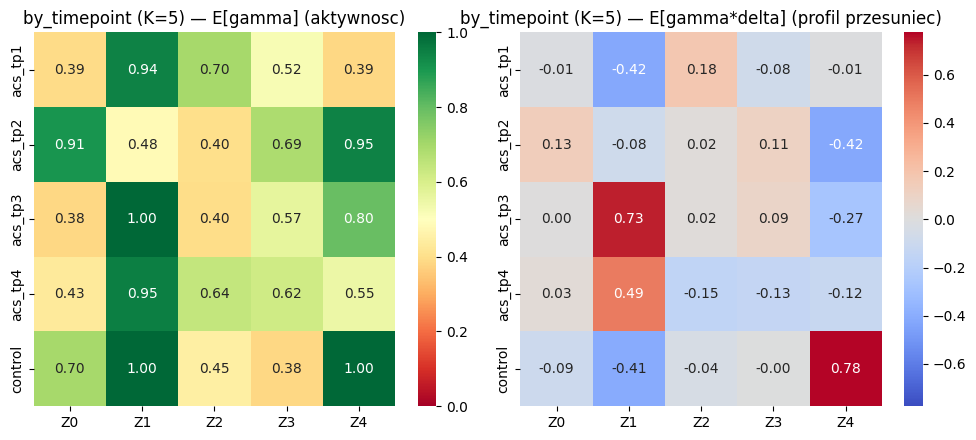

In [9]:
mode = 'by_timepoint'
m  = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
print(f"ELBO  cohort={out['elbo']:.0f}   baseline={float(mb.elbo_sequence[-1]):.0f}")
plot_cohort_effects(out, HEADLINE_K, 'by_timepoint (K=5)')


### 2a — Profil kohortowy: CohortFACTM vs baseline

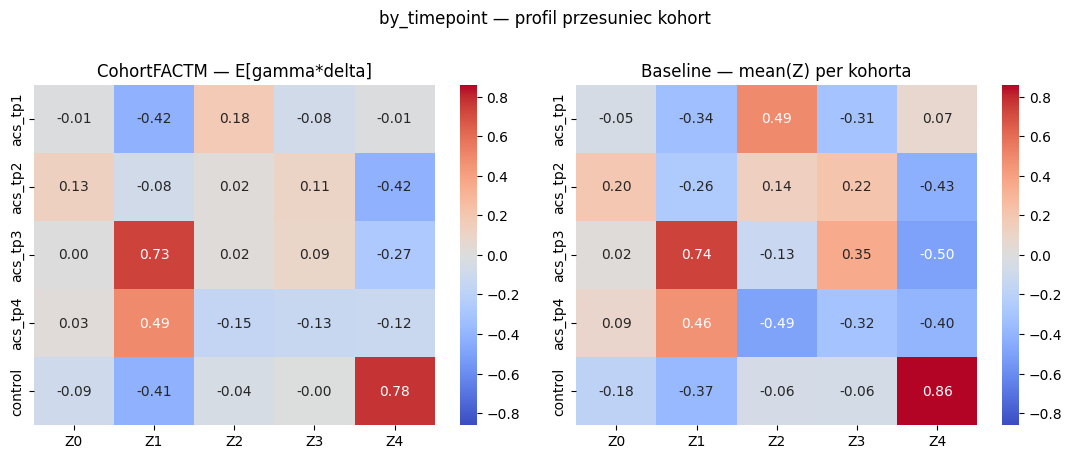

In [10]:
mode = 'by_timepoint'
d   = get_data(mode)
mb  = get_fit(mode, 'baseline', K=HEADLINE_K)
mc  = get_fit(mode, 'cohort',   K=HEADLINE_K)
names, codes = np.unique(d.cohorts, return_inverse=True)
prof_base    = np.array([mb.get_latent_factors()[codes == i].mean(0)
                         for i in range(len(names))])
out          = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
prof_cohort  = out['E_gamma'] * out['E_delta']
fl   = [f'Z{k}' for k in range(HEADLINE_K)]
vmax = max(np.abs(prof_cohort).max(), np.abs(prof_base).max())

fig, axes = plt.subplots(1, 2, figsize=(11, 0.5 * len(names) + 2))
sns.heatmap(prof_cohort, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-vmax, vmax=vmax, xticklabels=fl, yticklabels=names, ax=axes[0])
axes[0].set_title('CohortFACTM — E[gamma*delta]')
sns.heatmap(prof_base, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-vmax, vmax=vmax, xticklabels=fl, yticklabels=names, ax=axes[1])
axes[1].set_title('Baseline — mean(Z) per kohorta')
plt.suptitle('by_timepoint — profil przesuniec kohort', y=1.01)
plt.tight_layout(); plt.show()

### 2b — Sweep K = 3...10, 15, 20

In [11]:
#K_RANGE    = [3, 4, 5, 6, 7, 8, 9, 10, 15, 20]
K_RANGE    = [3, 4, 5, 6, 7, 8, 9]

ACTIVE_THR = 0.5
views_obj  = get_data(mode).views
rows = []
for K in K_RANGE:
    mc  = get_fit(mode, 'cohort',   K=K)
    mbk = get_fit(mode, 'baseline', K=K)
    E_g, _ = cohort_gamma_delta(mc, K)
    g_mean  = E_g.mean(axis=0)
    rows.append({'K': K,
                 'elbo_cohort':   float(mc.elbo_sequence[-1]),
                 'elbo_baseline': float(mbk.elbo_sequence[-1]),
                 'n_active':      int((g_mean > ACTIVE_THR).sum()),
                 'n_relevant_W':  n_relevant_factors(mc, 0),
                 'R2_cohort':     mean_r2(mc,  views_obj),
                 'R2_baseline':   mean_r2(mbk, views_obj)})
df_K = pd.DataFrame(rows)
df_K['elbo_gap'] = df_K['elbo_cohort'] - df_K['elbo_baseline']
print(df_K.round(3).to_string(index=False))

Pretraining FA
Fitting model


100%|██████████| 500/500 [00:31<00:00, 15.98it/s]


  fitted by_timepoint/cohort/K=3/pi=0.5 in 31s
Pretraining FA
Fitting model


100%|██████████| 500/500 [00:29<00:00, 17.08it/s]


  fitted by_timepoint/baseline/K=3/pi=None in 29s
Pretraining FA
Fitting model


...

  fitted by_timepoint/baseline/K=8/pi=None in 77s
Pretraining FA
Fitting model


100%|██████████| 500/500 [02:14<00:00,  3.71it/s]


  fitted by_timepoint/cohort/K=9/pi=0.5 in 135s
Pretraining FA
Fitting model


100%|██████████| 500/500 [01:52<00:00,  4.45it/s]

  fitted by_timepoint/baseline/K=9/pi=None in 113s
 K  elbo_cohort  elbo_baseline  n_active  n_relevant_W  R2_cohort  R2_baseline  elbo_gap
 3  -230290.205    -230291.264         3             2      0.096        0.096     1.059
 4  -230146.734    -230146.305         4             3      0.116        0.115    -0.429
 5  -230189.702    -230195.660         5             4      0.144        0.143     5.958
 6  -230209.625    -230184.039         5             5      0.158        0.157   -25.586
 7  -230404.029    -230386.624         5             6      0.179        0.179   -17.404
 8  -230485.442    -230458.537         6             6      0.251        0.251   -26.904
 9  -230819.144    -230793.851         6             6      0.264        0.264   -25.292


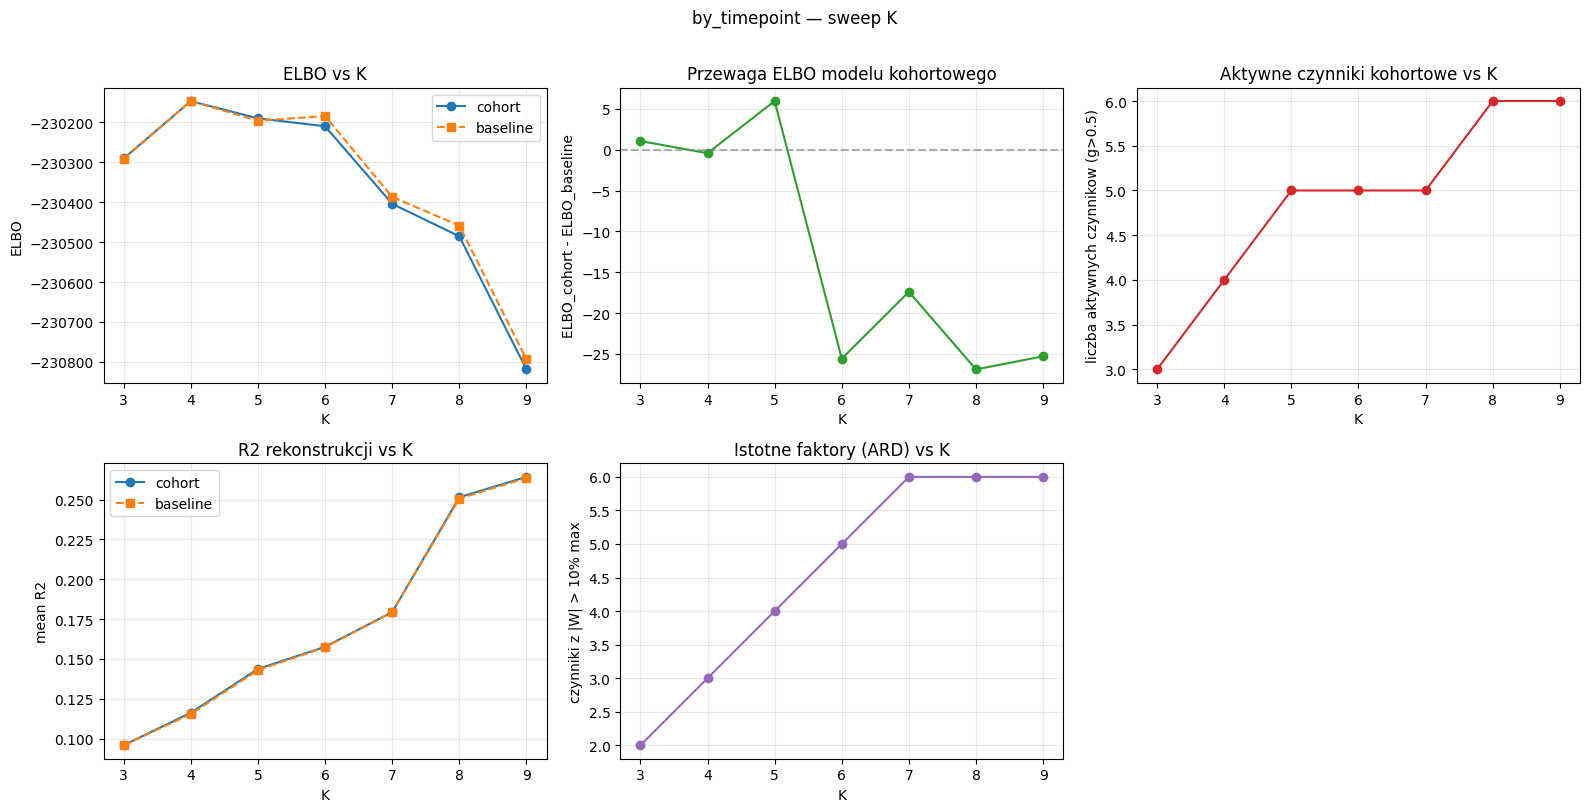

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0,0].plot(df_K['K'], df_K['elbo_cohort'],   'o-', label='cohort')
axes[0,0].plot(df_K['K'], df_K['elbo_baseline'], 's--', label='baseline')
axes[0,0].set_xlabel('K'); axes[0,0].set_ylabel('ELBO')
axes[0,0].set_title('ELBO vs K'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(df_K['K'], df_K['elbo_gap'], 'o-', color='C2')
axes[0,1].axhline(0, color='gray', ls='--', alpha=0.6)
axes[0,1].set_xlabel('K'); axes[0,1].set_ylabel('ELBO_cohort - ELBO_baseline')
axes[0,1].set_title('Przewaga ELBO modelu kohortowego'); axes[0,1].grid(alpha=0.3)

axes[0,2].plot(df_K['K'], df_K['n_active'], 'o-', color='C3')
axes[0,2].set_xlabel('K'); axes[0,2].set_ylabel('liczba aktywnych czynnikow (g>0.5)')
axes[0,2].set_title('Aktywne czynniki kohortowe vs K'); axes[0,2].grid(alpha=0.3)

axes[1,0].plot(df_K['K'], df_K['R2_cohort'],   'o-', label='cohort')
axes[1,0].plot(df_K['K'], df_K['R2_baseline'], 's--', label='baseline')
axes[1,0].set_xlabel('K'); axes[1,0].set_ylabel('mean R2')
axes[1,0].set_title('R2 rekonstrukcji vs K'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(df_K['K'], df_K['n_relevant_W'], 'o-', color='C4')
axes[1,1].set_xlabel('K'); axes[1,1].set_ylabel('czynniki z |W| > 10% max')
axes[1,1].set_title('Istotne faktory (ARD) vs K'); axes[1,1].grid(alpha=0.3)

axes[1,2].axis('off')
plt.suptitle('by_timepoint — sweep K', y=1.01)
plt.tight_layout(); plt.show()

## 3 — Eksperyment 2: `grouped` (control / acs\_acute / acs\_recovery)

Grupowanie biologiczne: `control` (TP0), `acs_acute` (TP1+TP2, szczyt uszkodzenia
miokardium wg CK/Troponiny), `acs_recovery` (TP3+TP4, zdrowienie przed wypisem).

Pretraining FA
Fitting model


100%|██████████| 500/500 [00:46<00:00, 10.71it/s]


  fitted grouped/cohort/K=5/pi=0.5 in 47s
Pretraining FA
Fitting model


100%|██████████| 500/500 [00:49<00:00, 10.17it/s]


  fitted grouped/baseline/K=5/pi=None in 49s
ELBO  cohort=-230184   baseline=-230196


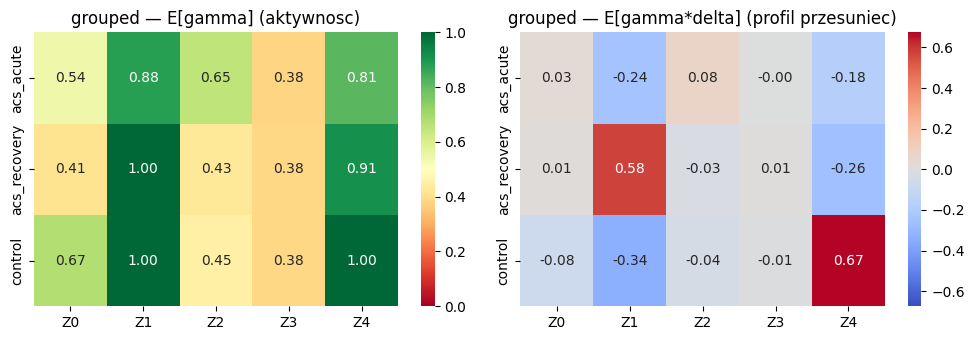

In [13]:
mode = 'grouped'
m  = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
print(f"ELBO  cohort={out['elbo']:.0f}   baseline={float(mb.elbo_sequence[-1]):.0f}")
plot_cohort_effects(out, HEADLINE_K, 'grouped')

## 4 — Eksperyment 3: `acs_vs_control` (control / acs)

Najprostszy podział: CCS+Non-CCS (TP0) vs wszystkie punkty ACS (TP1-4).
Odpowiednik `binary` w notebooku COVID.

Pretraining FA
Fitting model


100%|██████████| 500/500 [00:49<00:00, 10.05it/s]


  fitted acs_vs_control/cohort/K=5/pi=0.5 in 50s
Pretraining FA
Fitting model


100%|██████████| 500/500 [00:47<00:00, 10.58it/s]


  fitted acs_vs_control/baseline/K=5/pi=None in 47s
ELBO  cohort=-230190   baseline=-230196


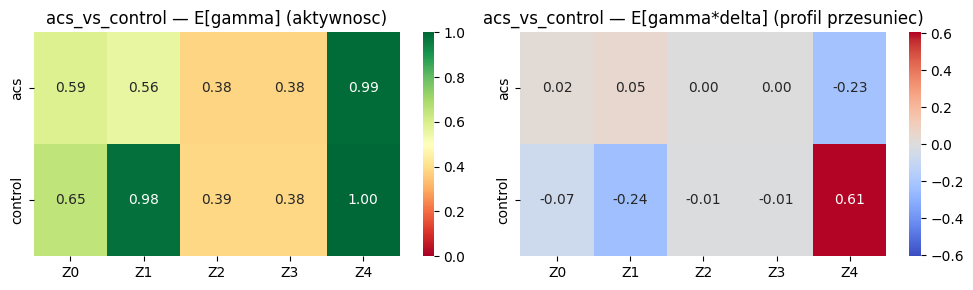

In [14]:
mode = 'acs_vs_control'
m  = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb = get_fit(mode, 'baseline', K=HEADLINE_K)
out = extract_cohort_effects(m, get_data(mode).cohorts, K=HEADLINE_K)
print(f"ELBO  cohort={out['elbo']:.0f}   baseline={float(mb.elbo_sequence[-1]):.0f}")
plot_cohort_effects(out, HEADLINE_K, 'acs_vs_control')

## 5 — Struktura odleglosci kohort i korelacja z gradientem czasowym ACS

**Exp 4** — Parami odleglosc L2 miedzy pozycjami kohort `E[gamma*delta]`.
Oczekiwanie: `control` daleko od `acs_tp2` (szczyt); `acs_tp4` blizej `control`.

**Exp 5** — Spearman: czy odleglosc utajona koreluje z odlegloscia na osi czasu?
Gradacja: control=0, acs_tp1=1, acs_tp2=2, acs_tp3=3, acs_tp4=4.

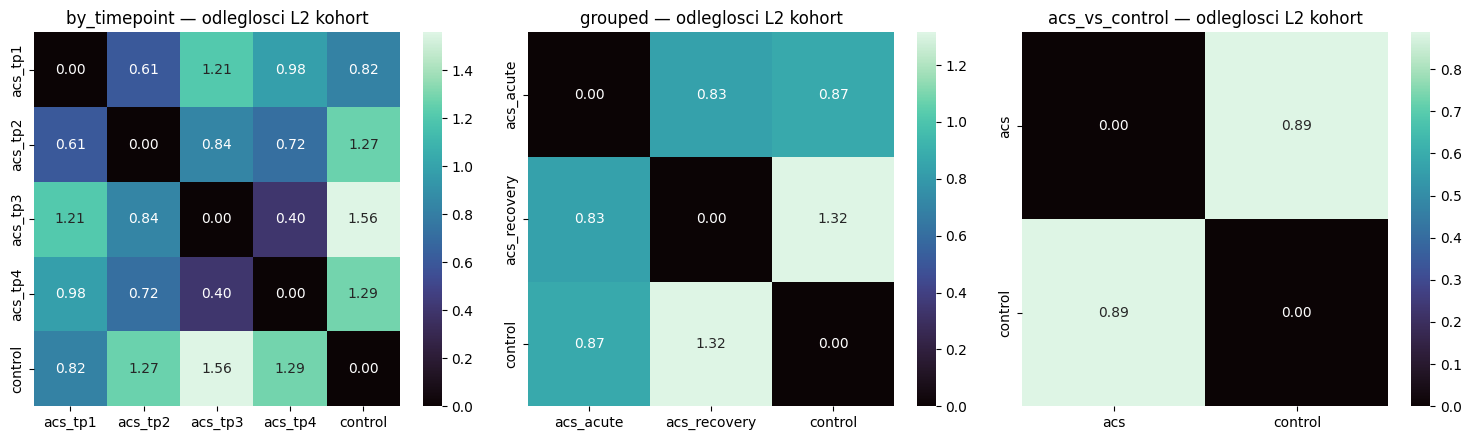

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, mode in zip(axes, MODES):
    mc  = get_fit(mode, 'cohort', K=HEADLINE_K)
    out = extract_cohort_effects(mc, get_data(mode).cohorts, K=HEADLINE_K)
    M   = out['E_gamma'] * out['E_delta']
    D   = cohort_dist(M)
    sns.heatmap(D, annot=True, fmt='.2f', cmap='mako',
                xticklabels=out['cohorts'], yticklabels=out['cohorts'], ax=ax)
    ax.set_title(f'{mode} — odleglosci L2 kohort')
plt.tight_layout(); plt.show()

In [16]:
rows = []
for mode in ['grouped', 'by_timepoint']:
    mc   = get_fit(mode, 'cohort',   K=HEADLINE_K)
    mb   = get_fit(mode, 'baseline', K=HEADLINE_K)
    d    = get_data(mode)
    out  = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
    names = out['cohorts']
    D_fit  = cohort_dist(out['E_gamma'] * out['E_delta'])
    Zh     = mb.get_latent_factors()
    Z_means = np.array([Zh[d.cohorts == c].mean(axis=0) for c in names])
    D_base  = cohort_dist(Z_means)
    tord   = np.array([timepoint_from_label(c) for c in names])
    D_time = np.abs(tord[:, None] - tord[None, :])
    tri    = np.triu_indices(len(names), 1)
    r_c = float(spearmanr(D_fit[tri],  D_time[tri])[0])
    r_b = float(spearmanr(D_base[tri], D_time[tri])[0])
    rows.append({'mode': mode, 'n_cohorts': len(names),
                 'corr_cohort': r_c, 'corr_baseline': r_b,
                 'gap (cohort-baseline)': r_c - r_b})
print(pd.DataFrame(rows).round(3).to_string(index=False))

        mode  n_cohorts  corr_cohort  corr_baseline  gap (cohort-baseline)
     grouped          3        0.866          0.866                  0.000
by_timepoint          5        0.782          0.871                 -0.089


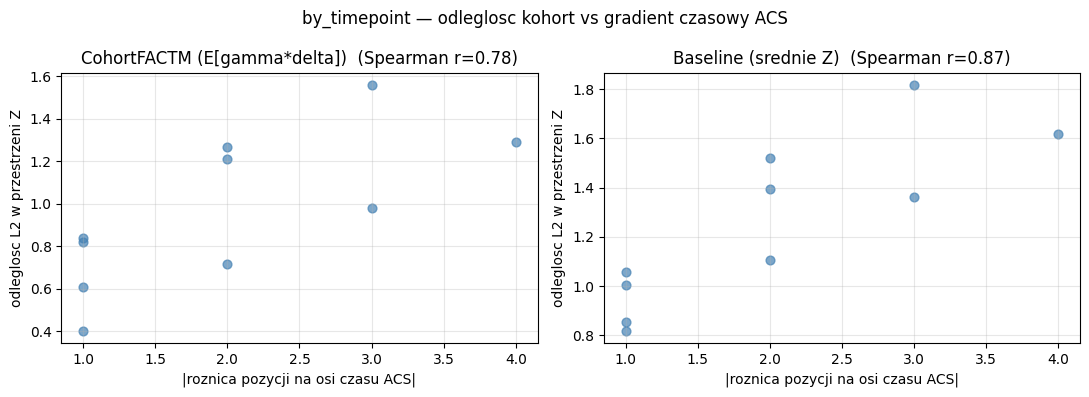

In [17]:
mode = 'by_timepoint'
mc   = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb   = get_fit(mode, 'baseline', K=HEADLINE_K)
d    = get_data(mode)
out  = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
names = out['cohorts']
D_c   = cohort_dist(out['E_gamma'] * out['E_delta'])
Zh    = mb.get_latent_factors()
D_b   = cohort_dist(np.array([Zh[d.cohorts == c].mean(axis=0) for c in names]))
tord  = np.array([timepoint_from_label(c) for c in names])
D_t   = np.abs(tord[:, None] - tord[None, :])
tri   = np.triu_indices(len(names), 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, D_fit, label in zip(axes, [D_c, D_b],
                             ['CohortFACTM (E[gamma*delta])', 'Baseline (srednie Z)']):
    r = float(spearmanr(D_fit[tri], D_t[tri])[0])
    ax.scatter(D_t[tri], D_fit[tri], s=40, alpha=0.7, color='steelblue')
    ax.set_xlabel('|roznica pozycji na osi czasu ACS|')
    ax.set_ylabel('odleglosc L2 w przestrzeni Z')
    ax.set_title(f'{label}  (Spearman r={r:.2f})')
    ax.grid(alpha=0.3)
plt.suptitle('by_timepoint — odleglosc kohort vs gradient czasowy ACS')
plt.tight_layout(); plt.show()

## 6 — Test `pi` (sweep `pi` dla `K in {3, 5, 10}`)

`pi = P(gamma=1)` — prior spike-and-slab decydujacy, jak chetnie model uznaje
czynnik za rozniacy kohorty. Monitorujemy: liczbe aktywnych czynnikow, ELBO, mapy aktywacji.

In [18]:
PI_GRID    = [0.1, 0.3, 0.5, 0.7, 0.9]
K_FOR_PI   = [3, 5, 10]
mode       = 'by_timepoint'
ACTIVE_THR = 0.5

rows = []
gamma_maps = {}
for K in K_FOR_PI:
    cols = []
    for pi in PI_GRID:
        mp = get_fit(mode, 'cohort', K=K, pi=pi)
        E_g, _ = cohort_gamma_delta(mp, K)
        g_mean  = E_g.mean(axis=0)
        cols.append(g_mean)
        rows.append({'K': K, 'pi': pi,
                     'n_active':       int((g_mean > ACTIVE_THR).sum()),
                     'max_mean_gamma': float(g_mean.max()),
                     'elbo':           float(mp.elbo_sequence[-1])})
    gamma_maps[K] = np.array(cols).T
df_pi = pd.DataFrame(rows)
print(df_pi.round(3).to_string(index=False))

Pretraining FA
Fitting model


100%|██████████| 500/500 [00:32<00:00, 15.62it/s]


  fitted by_timepoint/cohort/K=3/pi=0.1 in 32s
Pretraining FA
Fitting model


100%|██████████| 500/500 [00:33<00:00, 14.93it/s]


  fitted by_timepoint/cohort/K=3/pi=0.3 in 34s
Pretraining FA
Fitting model


...

  fitted by_timepoint/cohort/K=10/pi=0.5 in 99s
Pretraining FA
Fitting model


100%|██████████| 500/500 [02:19<00:00,  3.58it/s]


  fitted by_timepoint/cohort/K=10/pi=0.7 in 140s
Pretraining FA
Fitting model


100%|██████████| 500/500 [02:35<00:00,  3.22it/s]

  fitted by_timepoint/cohort/K=10/pi=0.9 in 156s
 K  pi  n_active  max_mean_gamma        elbo
 3 0.1         1           0.654 -230294.256
 3 0.3         1           0.787 -230291.966
 3 0.5         3           0.858 -230290.205
 3 0.7         3           0.916 -230288.762
 3 0.9         3           0.972 -230287.506
 5 0.1         1           0.634 -230194.471
 5 0.3         2           0.808 -230191.948
 5 0.5         5           0.876 -230189.702
 5 0.7         5           0.929 -230187.702
 5 0.9         5           0.977 -230185.856
10 0.1         2           0.672 -231361.575
10 0.3         3           0.776 -231361.541
10 0.5         7           0.847 -231360.878
10 0.7        10           0.907 -231359.821
10 0.9        10           0.968 -231358.509


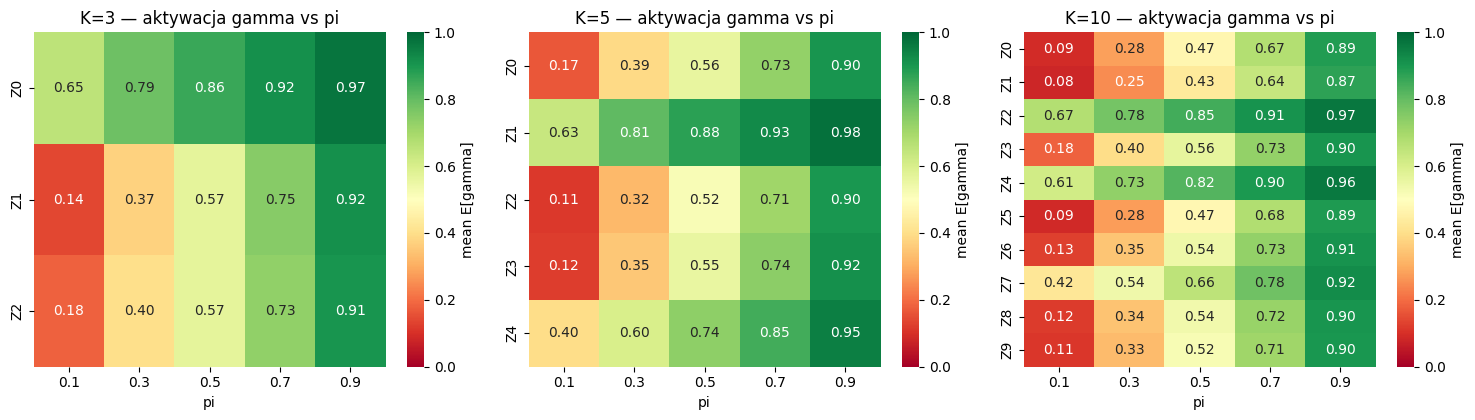

In [19]:
fig, axes = plt.subplots(1, len(K_FOR_PI),
                         figsize=(5 * len(K_FOR_PI), 0.8 + 0.35 * max(K_FOR_PI)))
for ax, K in zip(axes, K_FOR_PI):
    sns.heatmap(gamma_maps[K], annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
                xticklabels=[f'{p:g}' for p in PI_GRID],
                yticklabels=[f'Z{k}' for k in range(K)],
                cbar_kws={'label': 'mean E[gamma]'}, ax=ax)
    ax.set_xlabel('pi'); ax.set_title(f'K={K} — aktywacja gamma vs pi')
plt.tight_layout(); plt.show()

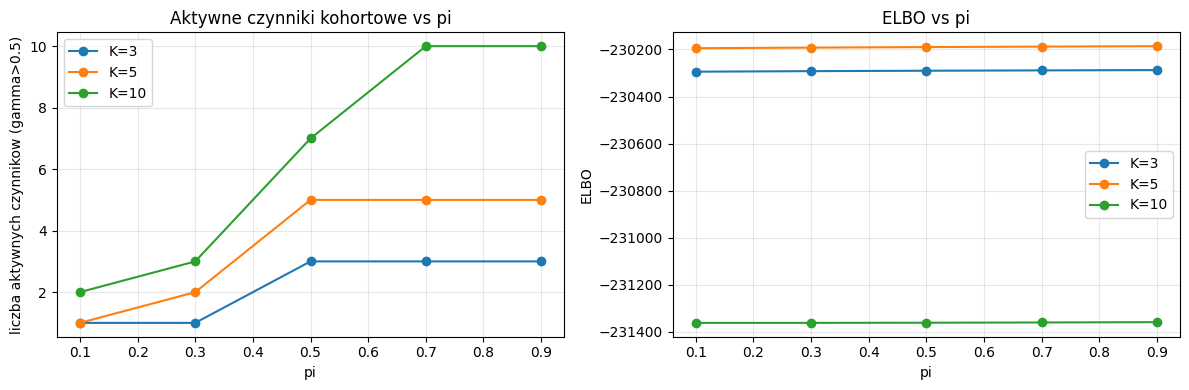

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for K in K_FOR_PI:
    sub = df_pi[df_pi['K'] == K]
    axes[0].plot(sub['pi'], sub['n_active'], 'o-', label=f'K={K}')
    axes[1].plot(sub['pi'], sub['elbo'],     'o-', label=f'K={K}')
axes[0].set_xlabel('pi'); axes[0].set_ylabel('liczba aktywnych czynnikow (gamma>0.5)')
axes[0].set_title('Aktywne czynniki kohortowe vs pi')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('pi'); axes[1].set_ylabel('ELBO')
axes[1].set_title('ELBO vs pi'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 6b — Wybor `pi`: 0.3 vs 0.5 vs 0.7

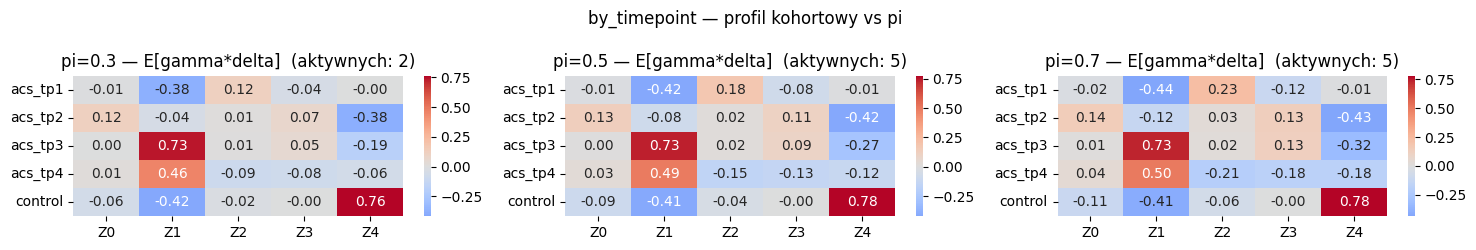

In [21]:
PIS  = [0.3, 0.5, 0.7]
mode = 'by_timepoint'
d    = get_data(mode)
names = np.array(sorted(np.unique(d.cohorts)))
fig, axes = plt.subplots(1, len(PIS), figsize=(5 * len(PIS), 0.5 + 0.4 * len(names)))
for ax, pi in zip(axes, PIS):
    m = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi)
    E_g, E_d = cohort_gamma_delta(m, HEADLINE_K)
    n_act = int((E_g.mean(0) > 0.5).sum())
    sns.heatmap(E_g * E_d, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                xticklabels=[f'Z{k}' for k in range(HEADLINE_K)],
                yticklabels=names, ax=ax)
    ax.set_title(f'pi={pi} — E[gamma*delta]  (aktywnych: {n_act})')
plt.suptitle('by_timepoint — profil kohortowy vs pi')
plt.tight_layout(); plt.show()

In [22]:
PIS  = [0.3, 0.5, 0.7]
rows = []
for mode in ['grouped', 'by_timepoint']:
    d     = get_data(mode)
    names = np.array(sorted(np.unique(d.cohorts)))
    tord  = np.array([timepoint_from_label(c) for c in names])
    D_time = np.abs(tord[:, None] - tord[None, :])
    tri   = np.triu_indices(len(names), 1)
    Zb    = get_fit(mode, 'baseline', K=HEADLINE_K).get_latent_factors()
    Zmb   = np.array([Zb[d.cohorts == c].mean(0) for c in names])
    row   = {'mode': mode,
             'baseline': round(float(spearmanr(cohort_dist(Zmb)[tri], D_time[tri])[0]), 3)}
    for pi in PIS:
        m = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi)
        E_g, E_d = cohort_gamma_delta(m, HEADLINE_K)
        D = cohort_dist(E_g * E_d)
        row[f'cohort_pi{pi}'] = round(float(spearmanr(D[tri], D_time[tri])[0]), 3)
    rows.append(row)
print('Korelacja odleglosci kohort z gradientem czasowym (wyzej = lepiej):')
print(pd.DataFrame(rows).to_string(index=False))

Pretraining FA
Fitting model


100%|██████████| 500/500 [00:35<00:00, 13.89it/s]


  fitted grouped/cohort/K=5/pi=0.3 in 36s
Pretraining FA
Fitting model


100%|██████████| 500/500 [00:37<00:00, 13.49it/s]

  fitted grouped/cohort/K=5/pi=0.7 in 37s
Korelacja odleglosci kohort z gradientem czasowym (wyzej = lepiej):
        mode  baseline  cohort_pi0.3  cohort_pi0.5  cohort_pi0.7
     grouped     0.866         0.866         0.866         0.866
by_timepoint     0.871         0.731         0.782         0.782


In [23]:
PIS  = [0.3, 0.5, 0.7]
rows = []
for mode in MODES:
    d = get_data(mode)
    _, codes = np.unique(d.cohorts, return_inverse=True)
    C    = len(np.unique(codes))
    labb = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(
               get_fit(mode, 'baseline', K=HEADLINE_K).get_latent_factors())
    row  = {'mode': mode, 'baseline_ARI': round(adjusted_rand_score(codes, labb), 3)}
    for pi in PIS:
        lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(
                  get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi).get_latent_factors())
        row[f'cohort_pi{pi}_ARI'] = round(adjusted_rand_score(codes, lab), 3)
    rows.append(row)
print('Odzysk kohort z Z_hat (ARI, wyzej = lepiej):')
print(pd.DataFrame(rows).to_string(index=False))

Pretraining FA
Fitting model


100%|██████████| 500/500 [00:36<00:00, 13.65it/s]


  fitted acs_vs_control/cohort/K=5/pi=0.3 in 37s
Pretraining FA
Fitting model


100%|██████████| 500/500 [00:37<00:00, 13.45it/s]

  fitted acs_vs_control/cohort/K=5/pi=0.7 in 37s
Odzysk kohort z Z_hat (ARI, wyzej = lepiej):
          mode  baseline_ARI  cohort_pi0.3_ARI  cohort_pi0.5_ARI  cohort_pi0.7_ARI
  by_timepoint         0.145             0.138             0.138             0.138
       grouped         0.146             0.236             0.236             0.236
acs_vs_control         0.004             0.079             0.079             0.079


## 7 — Struktura czynnikow Z (by\_timepoint, K=5)

1. Korelacje miedzy faktorami — macierz corr(Z) (off-diagonal ~0 = dobre).
2. Istotnosc faktorow — wariancja, energia W, korelacja Spearmana z timepoint.
3. Centroidy kohort — mean Z per kohorta.

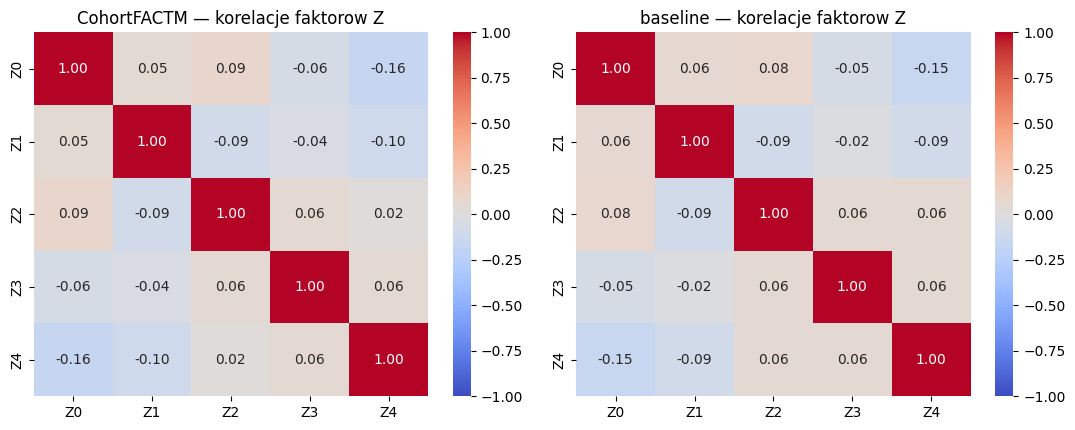

In [24]:
mode = 'by_timepoint'
mc   = get_fit(mode, 'cohort',   K=HEADLINE_K)
mb   = get_fit(mode, 'baseline', K=HEADLINE_K)
d    = get_data(mode)
fl   = [f'Z{k}' for k in range(HEADLINE_K)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (mdl, name) in zip(axes, [(mc, 'CohortFACTM'), (mb, 'baseline')]):
    sns.heatmap(np.corrcoef(mdl.get_latent_factors().T), annot=True, fmt='.2f',
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                xticklabels=fl, yticklabels=fl, ax=ax)
    ax.set_title(f'{name} — korelacje faktorow Z')
plt.tight_layout(); plt.show()

    var(Z[:,k])  |W0[:,k]| (energia)  |r(Z, timepoint)| Spear
Z0        0.105                0.231                    0.210
Z1        0.875                5.184                    0.481
Z2        0.509                6.718                    0.060
Z3        0.417                7.692                    0.039
Z4        0.847                4.312                    0.475

Faktor najsilniej powazany z timepoint: Z1  (|r|=0.481)


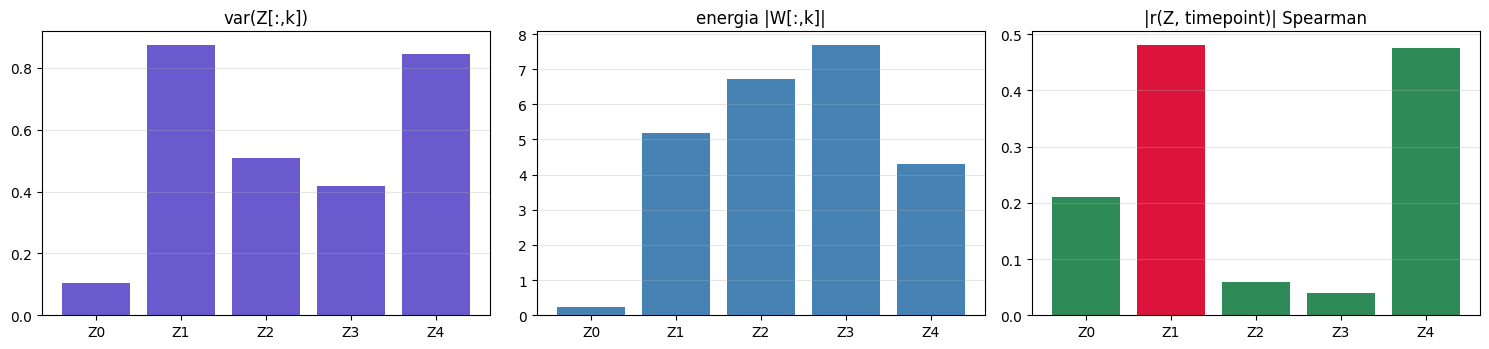

In [25]:
Z      = mc.get_latent_factors()
energy = np.linalg.norm(get_W(mc, 0), axis=0)
zvar   = Z.var(0)
tp_num = d.timepoints.astype(float)
fac_tp = np.array([abscorr_spear(Z[:, k], tp_num) for k in range(HEADLINE_K)])

tab = pd.DataFrame({'var(Z[:,k])':             zvar.round(3),
                    '|W0[:,k]| (energia)':      energy.round(3),
                    '|r(Z, timepoint)| Spear':  fac_tp.round(3)}, index=fl)
print(tab.to_string())
best = fl[int(np.nanargmax(fac_tp))]
print(f'\nFaktor najsilniej powazany z timepoint: {best}  (|r|={np.nanmax(fac_tp):.3f})')

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].bar(fl, zvar,   color='slateblue'); axes[0].set_title('var(Z[:,k])')
axes[1].bar(fl, energy, color='steelblue'); axes[1].set_title('energia |W[:,k]|')
colors = ['crimson' if k == int(np.nanargmax(fac_tp)) else 'seagreen'
          for k in range(HEADLINE_K)]
axes[2].bar(fl, fac_tp, color=colors);     axes[2].set_title('|r(Z, timepoint)| Spearman')
for ax in axes: ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

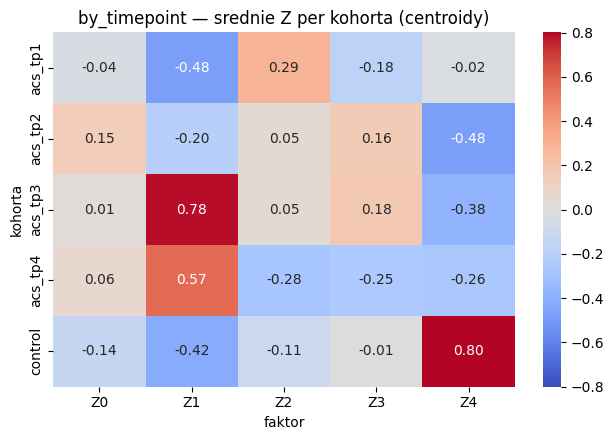

In [26]:
names, codes = np.unique(d.cohorts, return_inverse=True)
cent = np.array([Z[codes == i].mean(0) for i in range(len(names))])
vmax = np.abs(cent).max()
fig, ax = plt.subplots(figsize=(6.5, 0.5 * len(names) + 2))
sns.heatmap(cent, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-vmax, vmax=vmax, xticklabels=fl, yticklabels=names, ax=ax)
ax.set_title('by_timepoint — srednie Z per kohorta (centroidy)')
ax.set_xlabel('faktor'); ax.set_ylabel('kohorta')
plt.tight_layout(); plt.show()

## 8 — Klastrowanie i metryki separacji

Czy kohorty (fazy ACS) separuja sie w Z_hat?
Porownujemy CohortFACTM vs baseline na: silhouette, Davies-Bouldin,
Calinski-Harabasz, ARI, NMI, V-measure, ELBO, R2.

In [27]:
rows = []
for mode in MODES:
    d     = get_data(mode)
    codes = np.unique(d.cohorts, return_inverse=True)[1]
    for kind in ['cohort', 'baseline']:
        m    = get_fit(mode, kind, K=HEADLINE_K)
        mets = clustering_metrics(m.get_latent_factors(), codes)
        rows.append({'mode': mode, 'model': kind,
                     **{k: round(v, 3) for k, v in mets.items()}})
df_sep = pd.DataFrame(rows)
print(df_sep.to_string(index=False))

          mode    model  silhouette  davies_bouldin  calinski_harabasz  within_between
  by_timepoint   cohort      -0.018           4.046              7.226           1.210
  by_timepoint baseline      -0.023           3.957              5.463           1.359
       grouped   cohort       0.051           2.541             13.070           1.066
       grouped baseline       0.033           3.066              8.805           1.308
acs_vs_control   cohort       0.093           2.093             15.959           1.046
acs_vs_control baseline       0.068           2.670             10.086           1.335


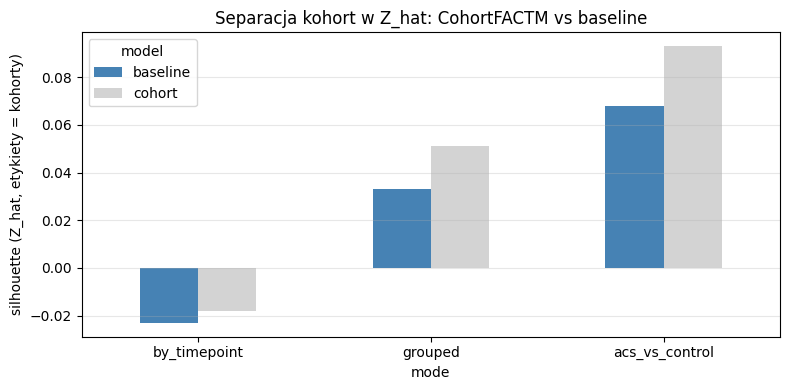

In [28]:
piv = df_sep.pivot(index='mode', columns='model', values='silhouette').loc[MODES]
ax  = piv.plot.bar(figsize=(8, 4), color=['steelblue', 'lightgray'], rot=0)
ax.set_ylabel('silhouette (Z_hat, etykiety = kohorty)')
ax.set_title('Separacja kohort w Z_hat: CohortFACTM vs baseline')
ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

Klastrowanie kohort (D_fit, by_timepoint):
 k  silhouette
 2       0.249
 3       0.323
 4       0.193


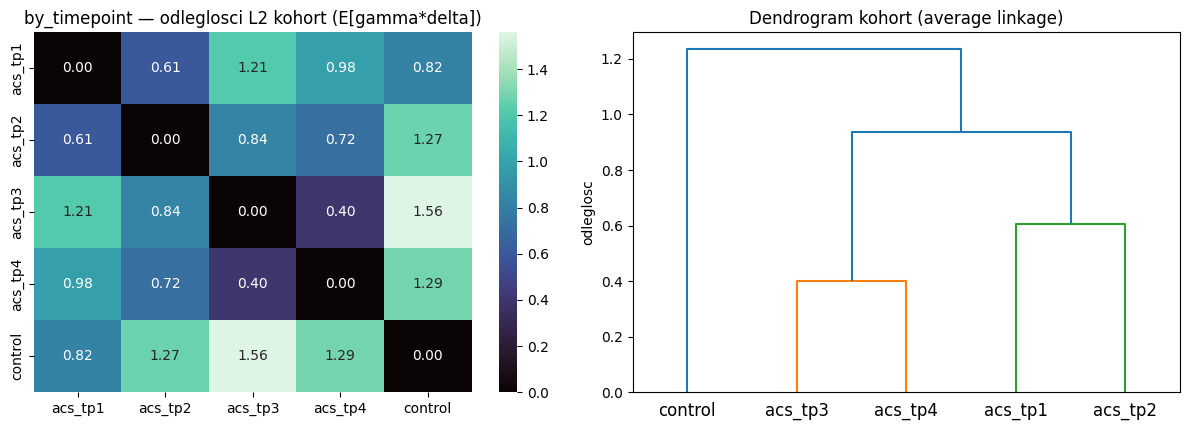

In [29]:
# Dendrogram kohort na podstawie odleglosci E[gamma*delta]
mode = 'by_timepoint'
mc   = get_fit(mode, 'cohort', K=HEADLINE_K)
d    = get_data(mode)
out  = extract_cohort_effects(mc, d.cohorts, K=HEADLINE_K)
names  = out['cohorts']
D_fit  = cohort_dist(out['E_gamma'] * out['E_delta'])

df_cc, _ = cluster_cohorts(D_fit, k_range=(2, 3, 4))
print('Klastrowanie kohort (D_fit, by_timepoint):')
print(df_cc.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
sns.heatmap(D_fit, annot=True, fmt='.2f', cmap='mako',
            xticklabels=names, yticklabels=names, ax=axes[0])
axes[0].set_title('by_timepoint — odleglosci L2 kohort (E[gamma*delta])')
Zlink = linkage(squareform(D_fit, checks=False), method='average')
dendrogram(Zlink, labels=list(names), ax=axes[1],
           color_threshold=0.7 * Zlink[:, 2].max())
axes[1].set_title('Dendrogram kohort (average linkage)')
axes[1].set_ylabel('odleglosc')
plt.tight_layout(); plt.show()

In [30]:
rows = []
for mode in MODES:
    d         = get_data(mode)
    views_obj = d.views
    _, codes  = np.unique(d.cohorts, return_inverse=True)
    C = len(np.unique(codes))
    for kind in ['cohort', 'baseline']:
        m   = get_fit(mode, kind, K=HEADLINE_K)
        Z   = m.get_latent_factors()
        lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(Z)
        h, comp, v = homogeneity_completeness_v_measure(codes, lab)
        rows.append({'mode': mode, 'model': kind, 'k': C,
                     'ELBO':       float(m.elbo_sequence[-1]),
                     'R2':         mean_r2(m, views_obj),
                     'silhouette': float(silhouette_score(Z, codes)),
                     'ARI':        adjusted_rand_score(codes, lab),
                     'NMI':        normalized_mutual_info_score(codes, lab),
                     'AMI':        adjusted_mutual_info_score(codes, lab),
                     'V_measure':  v,
                     'FMI':        fowlkes_mallows_score(codes, lab)})
df_full = pd.DataFrame(rows)
print(df_full.round(3).to_string(index=False))

          mode    model  k        ELBO    R2  silhouette   ARI   NMI    AMI  V_measure   FMI
  by_timepoint   cohort  5 -230189.702 0.144      -0.018 0.138 0.195  0.151      0.195 0.327
  by_timepoint baseline  5 -230195.660 0.143      -0.023 0.145 0.201  0.158      0.201 0.328
       grouped   cohort  3 -230183.785 0.144       0.051 0.236 0.309  0.296      0.309 0.514
       grouped baseline  3 -230195.660 0.143       0.033 0.146 0.188  0.173      0.188 0.457
acs_vs_control   cohort  2 -230189.859 0.143       0.093 0.079 0.259  0.253      0.259 0.595
acs_vs_control baseline  2 -230195.660 0.143       0.068 0.004 0.000 -0.008      0.000 0.629


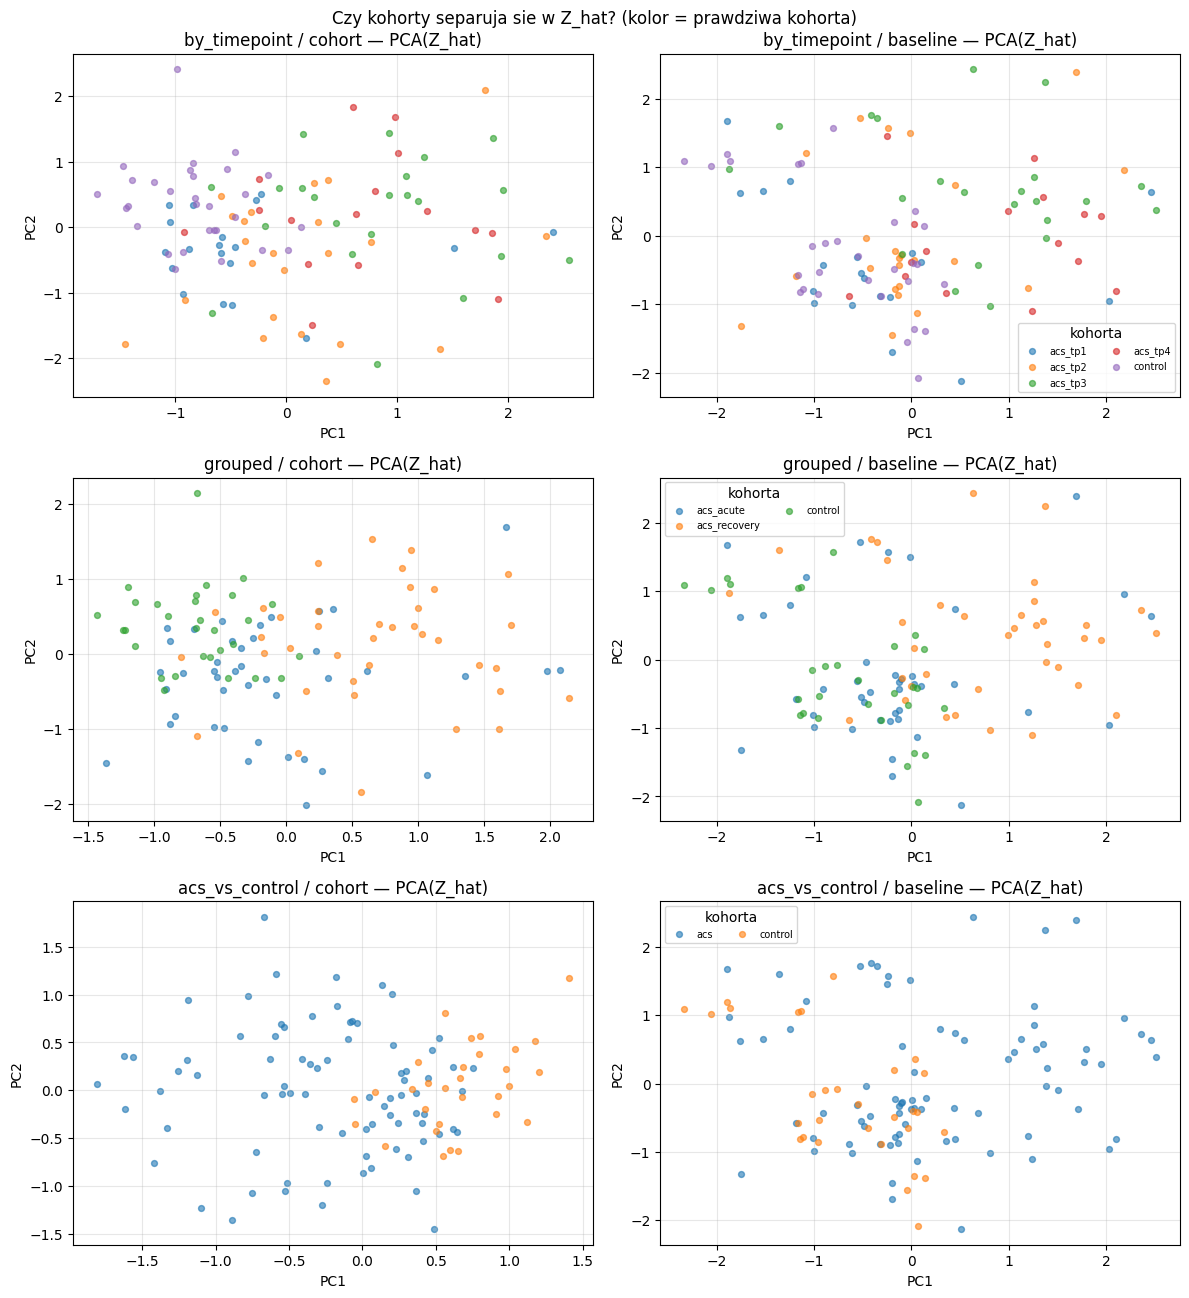

In [31]:
# PCA Z_hat: wizualna separacja kohort (cohort vs baseline)
fig, axes = plt.subplots(len(MODES), 2, figsize=(12, 4.4 * len(MODES)))
for r, mode in enumerate(MODES):
    d = get_data(mode)
    names, codes = np.unique(d.cohorts, return_inverse=True)
    for cax, kind in zip(axes[r], ['cohort', 'baseline']):
        Z = get_fit(mode, kind, K=HEADLINE_K).get_latent_factors()
        P = PCA(n_components=2).fit_transform(Z)
        for i, name in enumerate(names):
            msk = codes == i
            cax.scatter(P[msk, 0], P[msk, 1], s=18, alpha=0.6, label=name)
        cax.set_title(f'{mode} / {kind} — PCA(Z_hat)')
        cax.set_xlabel('PC1'); cax.set_ylabel('PC2'); cax.grid(alpha=0.3)
    axes[r, 1].legend(fontsize=7, ncol=2, title='kohorta')
plt.suptitle('Czy kohorty separuja sie w Z_hat? (kolor = prawdziwa kohorta)')
plt.tight_layout(); plt.show()

In [32]:
# Sweep pi: odzysk kohort (by_timepoint, K=5)
mode = 'by_timepoint'
d    = get_data(mode)
_, codes = np.unique(d.cohorts, return_inverse=True)
C    = len(np.unique(codes))
rows = []
for pi in PI_GRID:
    Z   = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi).get_latent_factors()
    lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(Z)
    h, comp, v = homogeneity_completeness_v_measure(codes, lab)
    rows.append({'pi': pi, 'k': C,
                 'silhouette': float(silhouette_score(Z, codes)),
                 'ARI':        float(adjusted_rand_score(codes, lab)),
                 'NMI':        float(normalized_mutual_info_score(codes, lab)),
                 'AMI':        float(adjusted_mutual_info_score(codes, lab)),
                 'V_measure':  float(v),
                 'FMI':        float(fowlkes_mallows_score(codes, lab))})
df_pi_clust = pd.DataFrame(rows)
print('Odzysk kohort (k-means, k=liczba kohort), by_timepoint:')
print(df_pi_clust.round(3).to_string(index=False))

Odzysk kohort (k-means, k=liczba kohort), by_timepoint:
 pi  k  silhouette   ARI   NMI   AMI  V_measure   FMI
0.1  5      -0.018 0.138 0.195 0.151      0.195 0.327
0.3  5      -0.018 0.138 0.195 0.151      0.195 0.327
0.5  5      -0.018 0.138 0.195 0.151      0.195 0.327
0.7  5      -0.017 0.138 0.195 0.151      0.195 0.327
0.9  5      -0.017 0.138 0.195 0.151      0.195 0.327


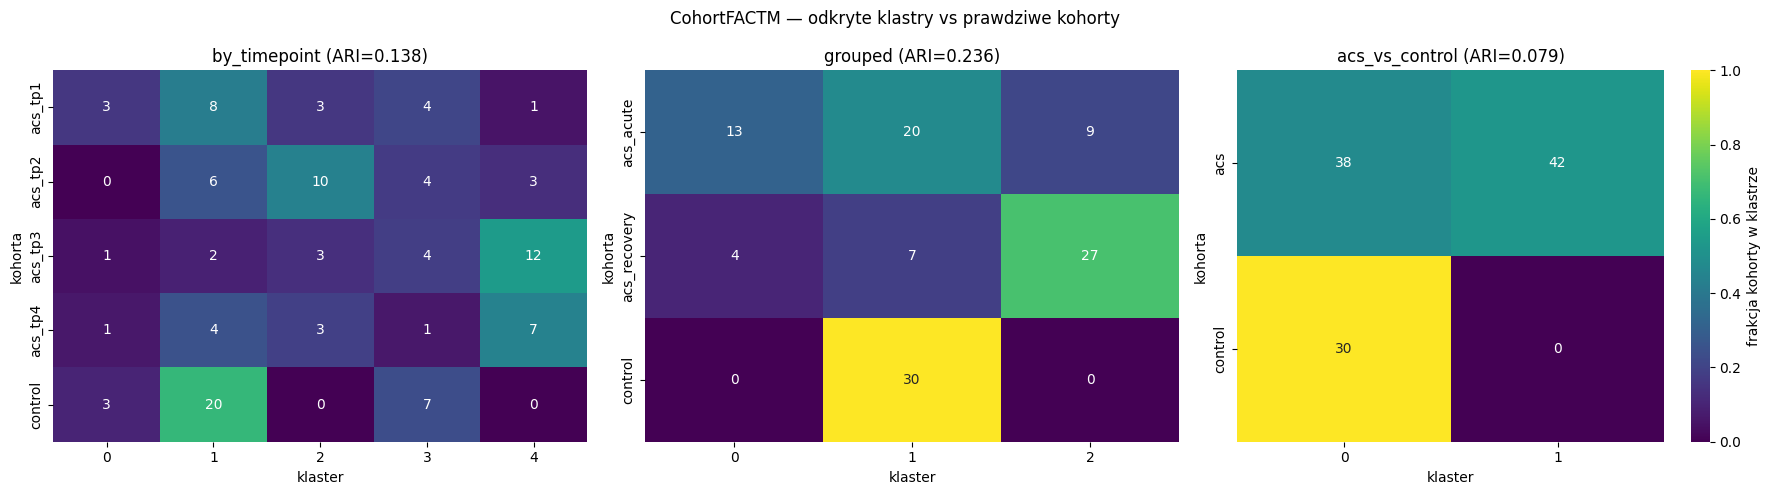

In [33]:
# Macierz zgodnosci: odkryte klastry vs prawdziwe kohorty
fig, axes = plt.subplots(1, len(MODES), figsize=(6 * len(MODES), 5))
for ax, mode in zip(axes, MODES):
    d = get_data(mode)
    names, codes = np.unique(d.cohorts, return_inverse=True)
    C   = len(names)
    Z   = get_fit(mode, 'cohort', K=HEADLINE_K).get_latent_factors()
    lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(Z)
    ct  = pd.crosstab(pd.Series(d.cohorts, name='kohorta'),
                      pd.Series(lab,       name='klaster'))
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    sns.heatmap(ct_norm, annot=ct.values, fmt='d', cmap='viridis',
                vmin=0, vmax=1, cbar=(ax is axes[-1]),
                cbar_kws={'label': 'frakcja kohorty w klastrze'}, ax=ax)
    ax.set_title(f'{mode} (ARI={adjusted_rand_score(codes, lab):.3f})')
plt.suptitle('CohortFACTM — odkryte klastry vs prawdziwe kohorty')
plt.tight_layout(); plt.show()

 pi  silhouette  davies_bouldin  calinski_harabasz  within_between
0.1      -0.018           4.071              7.153           1.218
0.3      -0.018           4.056              7.224           1.211
0.5      -0.018           4.046              7.226           1.210
0.7      -0.017           4.039              7.216           1.211
0.9      -0.017           4.034              7.201           1.212


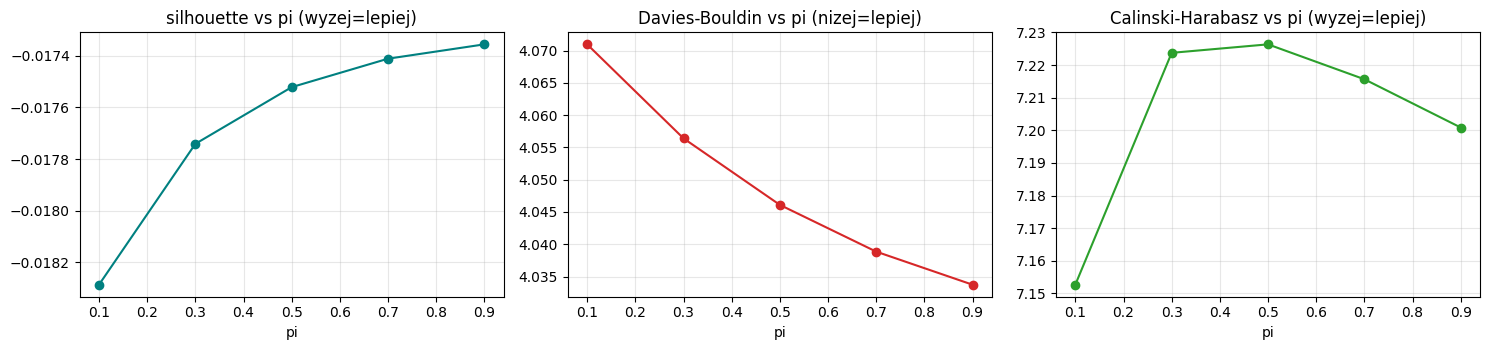

In [34]:
# Separacja kohort vs pi
mode  = 'by_timepoint'
codes = np.unique(get_data(mode).cohorts, return_inverse=True)[1]
rows  = []
for pi in PI_GRID:
    mp = get_fit(mode, 'cohort', K=HEADLINE_K, pi=pi)
    rows.append({'pi': pi, **clustering_metrics(mp.get_latent_factors(), codes)})
df_sil = pd.DataFrame(rows)
print(df_sil.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].plot(df_sil['pi'], df_sil['silhouette'],        'o-', color='teal')
axes[0].set_title('silhouette vs pi (wyzej=lepiej)')
axes[1].plot(df_sil['pi'], df_sil['davies_bouldin'],    'o-', color='C3')
axes[1].set_title('Davies-Bouldin vs pi (nizej=lepiej)')
axes[2].plot(df_sil['pi'], df_sil['calinski_harabasz'], 'o-', color='C2')
axes[2].set_title('Calinski-Harabasz vs pi (wyzej=lepiej)')
for ax in axes: ax.set_xlabel('pi'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9 — Wagi W i interpretacja biologiczna

* **9a** — heatmapy E[W] (cechy x czynniki) dla kazdego widoku
* **9b** — istotnosc faktorow: energia ARD, wariancja Z
* **9c** — top cechy per faktor (cytokiny, bialka, geny neutrofilow)
* **9d** — macierz R2: ile kazdy faktor wyjasnia z kazdego widoku / kohorty

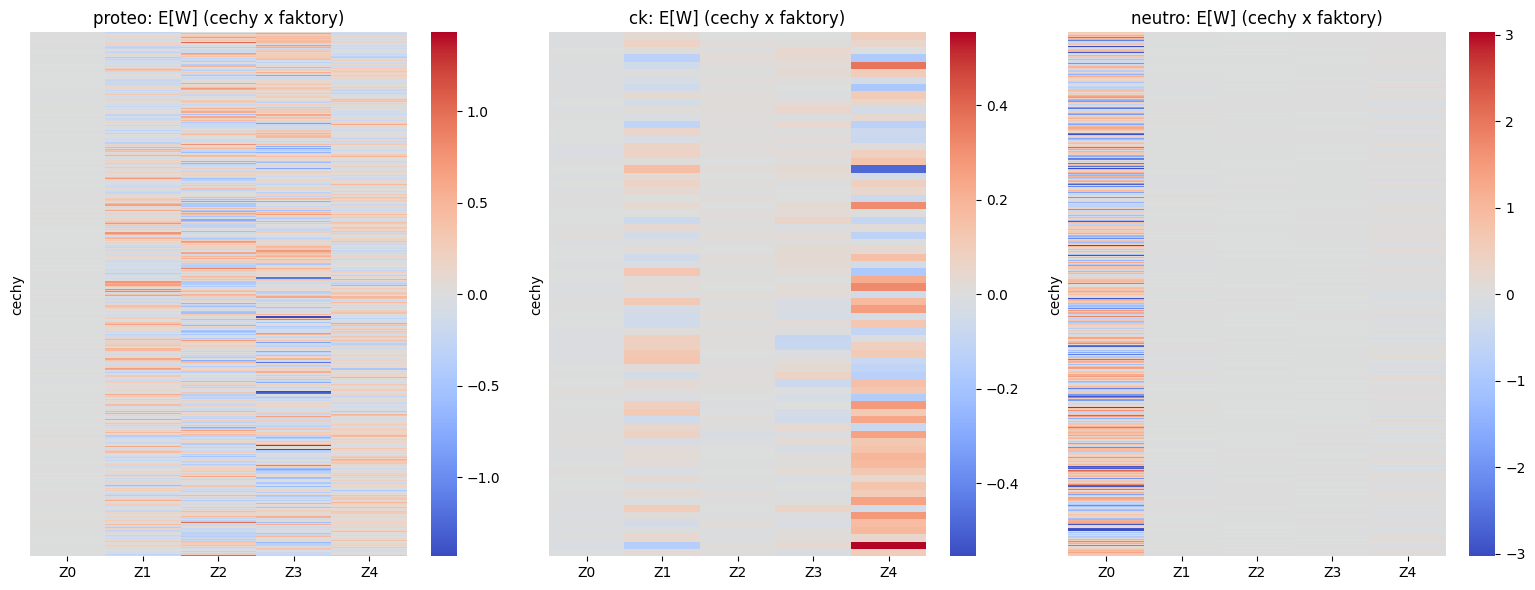

In [35]:
mode = 'by_timepoint'
mc   = get_fit(mode, 'cohort', K=HEADLINE_K)
fl   = [f'Z{k}' for k in range(HEADLINE_K)]

fig, axes = plt.subplots(1, len(VIEW_NAMES), figsize=(5.2 * len(VIEW_NAMES), 6))
for v, vname in enumerate(VIEW_NAMES):
    E_w  = get_W(mc, v)
    vmax = np.abs(E_w).max()
    sns.heatmap(E_w, cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
                xticklabels=fl, yticklabels=False, ax=axes[v])
    axes[v].set_title(f'{vname}: E[W] (cechy x faktory)')
    axes[v].set_ylabel('cechy')
plt.tight_layout(); plt.show()

In [36]:
W0        = get_W(mc, 0)
energy    = np.linalg.norm(W0, axis=0)
relevance = 1.0 / factor_alpha(mc, 0)
zvar      = mc.get_latent_factors().var(0)
tab = pd.DataFrame({'|W[:,k]| (energia)': energy.round(3),
                    '1/E[alpha] (ARD)':    relevance.round(3),
                    'var(Z[:,k])':         zvar.round(3)}, index=fl)
print(tab.to_string())

    |W[:,k]| (energia)  1/E[alpha] (ARD)  var(Z[:,k])
Z0               0.231             0.003        0.105
Z1               5.184             0.062        0.875
Z2               6.718             0.104        0.509
Z3               7.692             0.136        0.417
Z4               4.312             0.045        0.847


In [37]:
# Top-N cechy per faktor per widok
TOPN   = 10
fnames = {v: feature_names(v) for v in VIEW_NAMES}
rows   = []
for k in range(HEADLINE_K):
    for v, vname in enumerate(VIEW_NAMES):
        if not fnames[vname]: continue
        W   = get_W(mc, v)
        col = W[:, k]
        for direction, order in [('pos', np.argsort(col)[::-1][:TOPN]),
                                  ('neg', np.argsort(col)[:TOPN])]:
            rows.append({'faktor': f'Z{k}', 'widok': vname, 'kierunek': direction,
                         **{f'#{i+1}': f'{fnames[vname][j]} ({col[j]:+.2f})'
                            for i, j in enumerate(order)}})
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 200)
df_top = pd.DataFrame(rows)
print(df_top.to_string(index=False))

faktor  widok kierunek                          #1                          #2                      #3                      #4                           #5                          #6                           #7                         #8                             #9                        #10
    Z0 proteo      pos         KRT1_P04264 (+0.03)         KRT9_P35527 (+0.03)     LDHB_P07195 (+0.03)     SAA4_P35542 (+0.03)          AMBP_P02760 (+0.02)         HRNR_Q86YZ3 (+0.02)          CD5L_O43866 (+0.02) IGLV4.3_A0A075B6K6 (+0.02)        CPB2_A0A087WSY5 (+0.02)          C9_P02748 (+0.02)
    Z0 proteo      neg     SERPINA5_P05154 (-0.04)        C4BPB_P20851 (-0.03)     CAMP_J3KNB4 (-0.03)     SOD3_P08294 (-0.02) IGKV1D.13_A0A0B4J2D9 (-0.02)     SERPINA3_P01011 (-0.02)        KNG1_P01042.2 (-0.02)   GP1BA_A0A0C4DGZ8 (-0.02)    IGLV3.10_A0A075B6K4 (-0.02)      ICOSLG_K4DIA0 (-0.02)
    Z0     ck      pos             X6CKine (+0.01)                IL16 (+0.01)           IL28A (+0.00)    

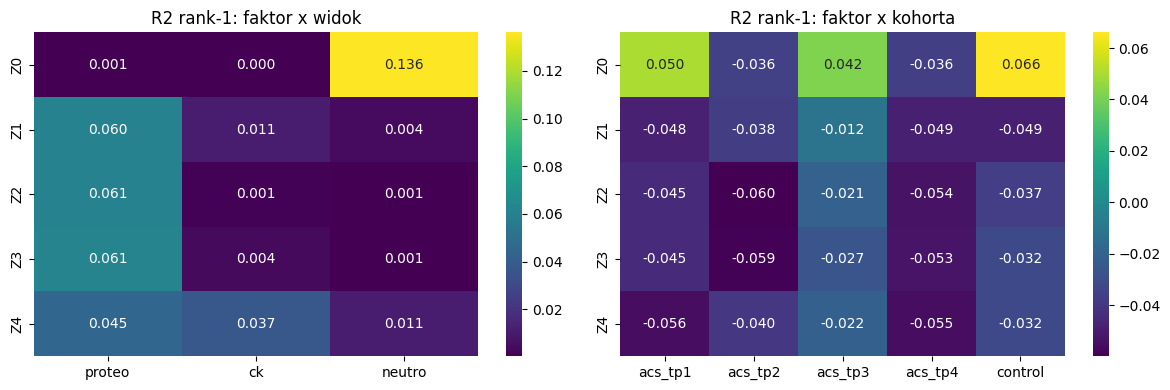

In [38]:
# Macierz R2: faktor x widok  i  faktor x kohorta
mode = 'by_timepoint'
d    = get_data(mode)
views_obj = d.views
mc   = get_fit(mode, 'cohort', K=HEADLINE_K)
Z    = mc.get_latent_factors()
names, codes = np.unique(d.cohorts, return_inverse=True)
fl   = [f'Z{k}' for k in range(HEADLINE_K)]

def var_expl(Y, Yh):
    return 1.0 - ((Y - Yh) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum()

R2_fv = np.zeros((HEADLINE_K, views_obj.num_simple))
for k in range(HEADLINE_K):
    for vi in range(views_obj.num_simple):
        Yh_k = np.outer(Z[:, k], get_W(mc, vi)[:, k])
        R2_fv[k, vi] = var_expl(np.asarray(views_obj.simple[vi].data), Yh_k)

Ycat = np.hstack([np.asarray(views_obj.simple[vi].data)
                  for vi in range(views_obj.num_simple)])
R2_fc = np.zeros((HEADLINE_K, len(names)))
for k in range(HEADLINE_K):
    Yh_k = np.hstack([np.outer(Z[:, k], get_W(mc, vi)[:, k])
                      for vi in range(views_obj.num_simple)])
    for ci in range(len(names)):
        m = codes == ci
        R2_fc[k, ci] = var_expl(Ycat[m], Yh_k[m])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(R2_fv, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=VIEW_NAMES, yticklabels=fl, ax=axes[0])
axes[0].set_title('R2 rank-1: faktor x widok')
sns.heatmap(R2_fc, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=names, yticklabels=fl, ax=axes[1])
axes[1].set_title('R2 rank-1: faktor x kohorta')
plt.tight_layout(); plt.show()

## 10 — Podsumowanie

Notebook przetestowal CohortFACTM na danych ACS/CCS (Munich cohort, Pekayvaz et al. 2024):

1. **Profile E[gamma] / E[gamma*delta]** dla trzech partycji
   (`by_timepoint`, `grouped`, `acs_vs_control`).
2. **Sweep K = 3...10, 15, 20** — liczba aktywnych czynnikow kohortowych, R2, ELBO gap.
3. **Struktura odleglosci kohort** — czy model rekonstruuje gradient ACS
   (control -> acs_tp1 -> acs_tp2 -> acs_tp3 -> acs_tp4)?
4. **Sweep pi** — optymalna wartosc prior spike-and-slab.
5. **Struktura Z** — nieskorelowane faktory; ktory koreluje z timepoint.
6. **Metryki separacji** — silhouette, ARI, NMI (cohort vs baseline).
7. **Ladunki W** — top cechy (cytokiny, bialka, geny neutrofilow) per faktor.

**Modele referencyjne z artykulu (MOFA):**
* **IAI** (Integrative ACS Ischemia, Factor 2) — rozroznia ACS od CCS,
  koreluje z timepoint; definiowany przez CD4+ T cells, monocyty, cytokiny.
* **IC** (Integrative CCS, Factor 1) — rozroznia CCS od Non-CCS
  (niedostepne w tym podziale — brak etykiet CCS/Non-CCS w HDF5).

CohortFACTM powinien wychwycic gradient analogiczny do IAI jako glowny czynnik kohortowy.